# TUGAS PRAKTIKUM 2 KECERDASAN KOMPUTASIONAL

| Informasi Mahasiswa | |
| :--- | :--- |
| **Nama** | Catherine Aprilia Harlina |
| **NRP** | 5054251012 |
| **Program Studi** | Rekayasa Kecerdasan Artifisial |
| **Mata Kuliah** | Kecerdasan Komputasional |

---

# 03. Propositional Logic

In [55]:
# =============================================================================
# Standard setup cell.
# Run this once, before any other cell in this notebook.
# =============================================================================
import importlib.util, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git"
ON_COLAB = "google.colab" in sys.modules

def ensure_dependencies():
    """Install only the packages this module actually uses."""
    required = {
        "networkx": "networkx", "numpy": "numpy", "pandas": "pandas",
        "matplotlib": "matplotlib", "ipywidgets": "ipywidgets",
        "PIL": "pillow", "pygments": "pygments",
    }
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_environment(start):
    """Locate the folder that holds logic.py and utils.py, searching upward."""
    for root in [start, *start.parents]:
        for candidate in sorted(root.rglob("logic.py")):
            if (candidate.parent / "utils.py").exists():
                return candidate.parent
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
start_dir = Path.cwd()
if ON_COLAB:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)], check=True)
    start_dir = clone_dir

ENV_DIR = find_environment(start_dir)
if ENV_DIR is None:
    raise RuntimeError("Environment folder not found.")

if str(ENV_DIR) not in sys.path:
    sys.path.insert(0, str(ENV_DIR))

import itertools, warnings
import pandas as pd

warnings.filterwarnings("ignore", message="no QP solver found")

from logic import *
from notebook import psource
from utils import *

print("Environment :", ENV_DIR)
print("Python      :", sys.version.split()[0])
print("Check       : tt_entails(P & Q, Q) =", tt_entails(expr("P & Q"), expr("Q")))

Environment : c:\Users\LEGION\Modul-Praktikum-KK-RKA-25\logics\praktikum\environment
Python      : 3.12.4
Check       : tt_entails(P & Q, Q) = True


### Soal 1

In [56]:
%pip install aima3

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
import itertools
from aima3.logic import expr, pl_true

X1, X2, X3 = expr('X1, X2, X3')
S = [X1, X2, X3]

print("Total kemungkinan model:", 2 ** len(S))

# 1. Salah satu pegawai sedang bekerja (At least 1 vs Exactly 1)
s1_inc = expr('X1 | X2 | X3')
s1_exc = expr('(X1 & ~X2 & ~X3) | (~X1 & X2 & ~X3) | (~X1 & ~X2 & X3)')

# 2. Dua pegawai sedang bekerja (At least 2 vs Exactly 2)
s2_inc = expr('(X1 & X2) | (X2 & X3) | (X1 & X3)')
s2_exc = expr('(X1 & X2 & ~X3) | (X1 & ~X2 & X3) | (~X1 & X2 & X3)')

# 3. Tidak semua pegawai sedang bekerja vs Tidak ada yang bekerja
s3 = expr('~(X1 & X2 & X3)')
s3_none = expr('~X1 & ~X2 & ~X3')

print('1. At least 1 model:', len(satisfying_models(s1_inc, S)), '| Exactly 1 model:', len(satisfying_models(s1_exc, S)))
print('2. At least 2 model:', len(satisfying_models(s2_inc, S)), '| Exactly 2 model:', len(satisfying_models(s2_exc, S)))
print('3. Tidak semua bekerja:', len(satisfying_models(s3, S)), '| Tidak ada yg bekerja:', len(satisfying_models(s3_none, S)))

Total kemungkinan model: 8
1. At least 1 model: 7 | Exactly 1 model: 3
2. At least 2 model: 4 | Exactly 2 model: 3
3. Tidak semua bekerja: 7 | Tidak ada yg bekerja: 1


analisis dari 8 kemungkinan kombinasi truth table nunjukin kalo nomor 1 dan 2 emang punya ambiguitas logika tergantung cara kita menginterpretasi batasannya; buat kasus nomor 1 versi inklusif (at least 1) dapet 7 model valid karena cuma nemu satu kondisi salah pas semua pegawai gak kerja, sedangkan versi eksklusif (exactly 1) cuma dapet 3 model yaitu pas salah satu aja yang bernilai true sementara dua lainnya false. lanjut ke nomor 2 versi inklusif (at least 2) nemu 4 model yang lolos karena ngikutin kondisi saat 2 atau 3 pegawai aktif barengan, beda sama versi eksklusif (exactly 2) yang cuma nyisain 3 model karena ngebuang opsi pas ketiga pegawai kerja semua. terus buat nomor 3 bentuk logika ~(X1 & X2 & X3) ngahasilin 7 model valid karena dia cuma negasiin kondisi pas ketiga pegawai kerja bareng, yang mana ini beda jauh sama konsep "tidak ada yang bekerja" ~X1 & ~X2 & ~X3 yang cuma punya 1 model valid doang pas ketiganya sama-sama false.

### Soal 2

In [58]:
import pandas as pd
import itertools
from aima3.logic import expr, pl_true

P, Q = expr('P, Q')
l, r = ~(P & Q), ~P | ~Q

d = [{'P': p, 'Q': q, 'LHS': pl_true(l, {P: p, Q: q}), 'RHS': pl_true(r, {P: p, Q: q})} for p, q in itertools.product([False, True], repeat=2)]
df = pd.DataFrame(d)
df['eq'] = df['LHS'] == df['RHS']

print(df.to_string(index=False))
print('tautology?:', df['eq'].all())

    P     Q   LHS   RHS   eq
False False  True  True True
False  True  True  True True
 True False  True  True True
 True  True False False True
tautology?: True


analisis dari truth table yang dibangkitin pake pl_true nunjukin kalo di semua kombinasi nilai kebenaran P dan Q (4 model yang mungkin), nilai dari LHS ~(P & Q) selalu persis sama dengan nilai RHS ~P | ~Q yang dibuktiin dari kolom eq bernilai True buat seluruh baris. karena hasil evaluasi df['eq'].all() ngahasilin nilai True, ini ngebuktiin kalo kalimat ~(P & Q) <=> (~P | ~Q) merupakan sebuah tautologi, alias hukum de morgan terbukti valid secara logis di semua kondisi tanpa ada pengecualian.

### Soal 3

implikasi material P -> Q itu ekuivalen ama ~P | Q, yang awal liat emang ga intuitif kenapa pas P bernilai False hasil implikasinya tetep bernilai True (vacuously true), tapi konsep ini penting bgt pas bikin Knowledge Base (KB) di logical agent. di logika proposisi, KB itu kan gabungan dari semua rule yang di-AND-kan (KB = R1 & R2 & ...), misal kita punya rule "kalo ada breeze, maka ada pit" (B -> P). pas agent lagi di tile yang ga ada angin (B = False), rule ini gabisa dianggep salah/False cuma gara2 premisnya ga terjadi saat itu, karena kalo rule bernilai False pas B = False, seluruh isi KB bakal ikut ketarik jd False (KB = True & False & ... = False). dlm kondisi gini, M(KB) jd himpunan kosong alias KB jd unsatisfiable dan reasoning agent langsung crash gara2 gabisa nge-deduce fakta apa2 lagi, makanya pas premis P bernilai False, implikasi hrs tetep bernilai True biar KB tetep konsisten n agent tetep bisa jalanin penalaran.

# 04. Forward & Backward Chaining

In [59]:
# pyright: reportUndefinedVariable=false
# =============================================================================
# Standard setup cell.
# Run this once, before any other cell in this notebook.
# =============================================================================
import importlib.util
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git"
ON_COLAB = "google.colab" in sys.modules

def ensure_dependencies():
    """Install only the packages this module actually uses."""
    required = {
        "networkx": "networkx",
        "numpy": "numpy",
        "pandas": "pandas",
        "matplotlib": "matplotlib",
        "ipywidgets": "ipywidgets",
        "PIL": "pillow",
        "pygments": "pygments",
    }
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_environment(start):
    """Locate the folder that holds logic.py and utils.py, searching upward."""
    for root in [start, *start.parents]:
        for candidate in sorted(root.rglob("logic.py")):
            if (candidate.parent / "utils.py").exists():
                return candidate.parent
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
start_dir = Path.cwd()
if ON_COLAB:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(clone_dir)], check=True)
    start_dir = clone_dir

ENV_DIR = find_environment(start_dir)
if ENV_DIR is None:
    raise RuntimeError(
        "Environment folder not found. Make sure this notebook is opened from "
        "inside the Modul-Praktikum-KK-RKA-25 repository."
    )

if str(ENV_DIR) not in sys.path:
    sys.path.insert(0, str(ENV_DIR))

import itertools
import warnings
import pandas as pd

# qpsolvers is only used by the SVM code, which this module never touches.
warnings.filterwarnings("ignore", message="no QP solver found")

from logic import *     # type: ignore
from notebook import *  # type: ignore
from utils import *     # type: ignore

print("Environment :", ENV_DIR)
print("Python      :", sys.version.split()[0])
print("Check       : tt_entails(P & Q, Q) =", tt_entails(expr("P & Q"), expr("Q")))

Environment : c:\Users\LEGION\Modul-Praktikum-KK-RKA-25\logics\praktikum\environment
Python      : 3.12.4
Check       : tt_entails(P & Q, Q) = True


In [60]:
import textwrap
import matplotlib.pyplot as plt

def make_kb(facts, rules):
    kb = PropDefiniteKB()
    for sentence in [*facts, *rules]:
        kb.tell(expr(sentence))
    return kb

def _as_expr(value):
    return expr(value) if isinstance(value, str) else value

def _agenda_text(agenda):
    return " → ".join(str(item) for item in agenda) or "(kosong)"

def ask_forward(kb, query):
    goal = _as_expr(query)
    count = {}
    premise_index = {}

    for clause in kb.clauses:
        if clause.op != "==>":
            continue
        premises = conjuncts(clause.args[0])
        count[clause] = len(premises)
        for premise in premises:
            premise_index.setdefault(premise, []).append(clause)

    initial_facts = [
        clause for clause in kb.clauses if is_prop_symbol(clause.op)
    ]
    agenda = list(dict.fromkeys(initial_facts))
    known = set(agenda)
    inferred = set()
    rows = []

    while agenda:
        agenda_before = list(agenda)
        fact = agenda.pop()
        step = len(rows) + 1

        if fact == goal:
            rows.append({
                "langkah": step,
                "agenda sebelum": _agenda_text(agenda_before),
                "fact diproses": str(fact),
                "rule aktif": "-",
                "conclusion baru": "-",
                "agenda sesudah": _agenda_text(agenda),
                "keputusan": "Query ditemukan; proses berhenti.",
            })
            trace = pd.DataFrame(rows)
            trace.attrs["query"] = str(goal)
            return True, trace

        if fact in inferred:
            continue

        inferred.add(fact)
        fired_rules = []
        new_conclusions = []
        known_conclusions = []

        for clause in premise_index.get(fact, []):
            count[clause] -= 1
            if count[clause] != 0:
                continue

            conclusion = clause.args[1]
            fired_rules.append(str(clause))
            if conclusion in known:
                known_conclusions.append(str(conclusion))
            else:
                known.add(conclusion)
                agenda.append(conclusion)
                new_conclusions.append(str(conclusion))

        if not fired_rules:
            decision = "Belum ada rule baru yang seluruh premise-nya terpenuhi."
        else:
            messages = []
            if new_conclusions:
                messages.append(
                    "Tambahkan " + ", ".join(new_conclusions) + " ke agenda."
                )
            if known_conclusions:
                messages.append(
                    ", ".join(known_conclusions) + " sudah diketahui; tidak ditambahkan ulang."
                )
            decision = " ".join(messages)

        rows.append({
            "langkah": step,
            "agenda sebelum": _agenda_text(agenda_before),
            "fact diproses": str(fact),
            "rule aktif": ", ".join(fired_rules) or "-",
            "conclusion baru": ", ".join(new_conclusions) or "-",
            "agenda sesudah": _agenda_text(agenda),
            "keputusan": decision,
        })

    trace = pd.DataFrame(rows)
    trace.attrs["query"] = str(goal)
    return False, trace

def visualize_forward(trace):
    if trace.empty:
        print("Trace kosong: tidak ada fact yang dapat diproses.")
        return

    query = trace.attrs.get("query", "?")
    figure_height = max(2.4, 2.25 * len(trace))
    figure, axes = plt.subplots(
        len(trace), 1, figsize=(14, figure_height), squeeze=False
    )

    for axis, (_, row) in zip(axes[:, 0], trace.iterrows()):
        axis.set_xlim(0, 1)
        axis.set_ylim(0, 1)
        axis.axis("off")

        query_found = "Query ditemukan" in row["keputusan"]
        decision_color = "#d1fae5" if query_found else "#e0f2fe"

        axis.text(
            0.01, 0.72, f"Langkah {row['langkah']}",
            fontsize=12, fontweight="bold", va="center"
        )
        axis.text(
            0.14, 0.72,
            "Agenda sebelum\n" + textwrap.fill(row["agenda sebelum"], 22),
            fontsize=10, va="center", ha="center",
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "#f3f4f6", "edgecolor": "#6b7280"},
        )
        axis.annotate("", xy=(0.38, 0.72), xytext=(0.31, 0.72),
                      arrowprops={"arrowstyle": "->", "color": "#374151", "lw": 1.5})
        axis.text(
            0.43, 0.72, f"Proses fact\n{row['fact diproses']}",
            fontsize=10, va="center", ha="center",
            bbox={"boxstyle": "round,pad=0.5", "facecolor": "#fef3c7", "edgecolor": "#d97706"},
        )
        axis.annotate("", xy=(0.59, 0.72), xytext=(0.50, 0.72),
                      arrowprops={"arrowstyle": "->", "color": "#374151", "lw": 1.5})

        decision_text = (
            "Rule aktif: " + textwrap.fill(row["rule aktif"], 42)
            + "\nConclusion baru: " + row["conclusion baru"]
            + "\n" + textwrap.fill(row["keputusan"], 52)
        )
        axis.text(
            0.78, 0.72, decision_text,
            fontsize=9.5, va="center", ha="center",
            bbox={"boxstyle": "round,pad=0.55", "facecolor": decision_color, "edgecolor": "#0284c7"},
        )
        axis.text(
            0.14, 0.16,
            "Agenda sesudah: " + textwrap.fill(row["agenda sesudah"], 75),
            fontsize=9.5, va="center", ha="left",
        )
        axis.plot([0.01, 0.99], [0.02, 0.02], color="#d1d5db", linewidth=1)

    figure.suptitle(
        f"Visualisasi Forward Chaining — Query: {query}",
        fontsize=15, fontweight="bold", y=1.005,
    )
    figure.text(
        0.5, 0.002,
        "Agenda dibaca dari kiri ke kanan; item paling kanan diproses berikutnya.",
        ha="center", fontsize=9, color="#4b5563",
    )
    plt.tight_layout()
    plt.show()

def ask_backward(kb, query):
    goal = _as_expr(query)
    facts = {clause for clause in kb.clauses if is_prop_symbol(clause.op)}
    rules_by_conclusion = {}

    for clause in kb.clauses:
        if clause.op == "==>":
            premises, conclusion = parse_definite_clause(clause)
            rules_by_conclusion.setdefault(conclusion, []).append(
                (clause, premises)
            )

    rows = []

    def prove(current_goal, goals_in_branch, depth, parent_step):
        step = len(rows) + 1
        row_index = len(rows)
        rows.append({
            "langkah": step,
            "parent": parent_step if parent_step is not None else "-",
            "depth": depth,
            "goal": str(current_goal),
            "rule diperiksa": "-",
            "rule berhasil": "-",
            "keputusan": "Periksa goal.",
            "hasil": None,
        })

        if current_goal in facts:
            rows[row_index]["keputusan"] = "Goal sudah tersedia sebagai fact."
            rows[row_index]["hasil"] = True
            return True

        if current_goal in goals_in_branch:
            rows[row_index]["keputusan"] = (
                "Goal yang sama sudah diperiksa pada branch ini; branch dihentikan."
            )
            rows[row_index]["hasil"] = False
            return False

        supporting_rules = rules_by_conclusion.get(current_goal, [])
        if not supporting_rules:
            rows[row_index]["keputusan"] = (
                "Tidak ada fact atau rule yang menghasilkan goal."
            )
            rows[row_index]["hasil"] = False
            return False

        next_branch = goals_in_branch | {current_goal}
        tried_rules = []

        for clause, premises in supporting_rules:
            tried_rules.append(str(clause))
            premise_results = []
            for premise in premises:
                premise_result = prove(premise, next_branch, depth + 1, step)
                premise_results.append(premise_result)
                if not premise_result:
                    break

            if all(premise_results):
                rows[row_index]["rule diperiksa"] = " | ".join(tried_rules)
                rows[row_index]["rule berhasil"] = str(clause)
                rows[row_index]["keputusan"] = (
                    "Semua premise pada rule berhasil dibuktikan."
                )
                rows[row_index]["hasil"] = True
                return True

        rows[row_index]["rule diperiksa"] = " | ".join(tried_rules)
        rows[row_index]["keputusan"] = "Semua rule pendukung gagal."
        rows[row_index]["hasil"] = False
        return False

    found = prove(goal, set(), depth=0, parent_step=None)
    trace = pd.DataFrame(rows)
    trace.attrs["query"] = str(goal)
    return found, trace

def visualize_backward(trace):
    if trace.empty:
        print("Trace kosong: tidak ada goal yang diperiksa.")
        return

    query = trace.attrs.get("query", "?")
    max_depth = int(trace["depth"].max())
    node_count = len(trace)
    x_spacing = 2.7
    positions = {
        int(row["langkah"]): (float(row["depth"]) * x_spacing, -int(row["langkah"]))
        for _, row in trace.iterrows()
    }

    figure_width = max(12, 5 + (max_depth + 1) * 2.35)
    figure_height = max(5, 1.25 * node_count)
    figure, axis = plt.subplots(figsize=(figure_width, figure_height))

    for _, row in trace.iterrows():
        step = int(row["langkah"])
        parent = row["parent"]
        if parent == "-":
            continue
        parent_step = int(parent)
        parent_x, parent_y = positions[parent_step]
        child_x, child_y = positions[step]
        axis.annotate(
            "",
            xy=(child_x, child_y + 0.28),
            xytext=(parent_x, parent_y - 0.28),
            arrowprops={"arrowstyle": "->", "color": "#64748b", "lw": 1.4},
        )

    for _, row in trace.iterrows():
        step = int(row["langkah"])
        x, y = positions[step]
        decision = str(row["keputusan"])
        result = bool(row["hasil"])

        if result:
            facecolor, edgecolor = "#d1fae5", "#059669"
        else:
            facecolor, edgecolor = "#fee2e2", "#dc2626"

        successful_rule = str(row["rule berhasil"])
        rule_line = (
            "\nRule: " + textwrap.fill(successful_rule, 34)
            if successful_rule != "-"
            else ""
        )
        label = (
            f"Langkah {step} | Goal: {row['goal']}"
            f"\nHasil: {result}"
            f"{rule_line}"
            f"\n{textwrap.fill(decision, 38)}"
        )
        axis.text(
            x, y, label,
            ha="center", va="center", fontsize=9.2,
            bbox={
                "boxstyle": "round,pad=0.55",
                "facecolor": facecolor,
                "edgecolor": edgecolor,
                "linewidth": 1.4,
            },
        )

    axis.set_xlim(-1.8, max(1.8, max_depth * x_spacing + 1.8))
    axis.set_ylim(-node_count - 1, 0)
    axis.axis("off")
    axis.set_title(
        f"Visualisasi Backward Chaining — Query: {query}",
        fontsize=15, fontweight="bold", pad=20,
    )
    figure.text(
        0.5, 0.005,
        "Hijau = goal berhasil dibuktikan, merah = goal gagal dibuktikan.",
        ha="center", fontsize=9, color="#4b5563",
    )
    plt.tight_layout()
    plt.show()

### Soal 1

In [61]:
exercise_facts = ["A", "B", "C"]
exercise_rules = [
    "(A & B) ==> D",
    "(B & C) ==> E",
    "(D & E) ==> F",
    "F ==> G",
]

exercise_kb = make_kb(exercise_facts, exercise_rules)

print("Klausa dalam KB:")
print(exercise_kb.clauses)

print("\nDetail Premis dan Konklusi tiap Rule:")
for rule in exercise_rules:
    premises, conclusion = parse_definite_clause(expr(rule))
    print(f"Rule: {rule:<15} | Premis: {premises} | Konklusi: {conclusion}")

Klausa dalam KB:
[A, B, C, ((A & B) ==> D), ((B & C) ==> E), ((D & E) ==> F), (F ==> G)]

Detail Premis dan Konklusi tiap Rule:
Rule: (A & B) ==> D   | Premis: [A, B] | Konklusi: D
Rule: (B & C) ==> E   | Premis: [B, C] | Konklusi: E
Rule: (D & E) ==> F   | Premis: [D, E] | Konklusi: F
Rule: F ==> G         | Premis: [F] | Konklusi: G


### Soal 2

G berhasil dibuktikan? True


,langkah,agenda sebelum,fact diproses,rule aktif,conclusion baru,agenda sesudah,keputusan
0,1,A → B → C,C,-,-,A → B,Belum ada rule baru yang seluruh premise-nya t...
1,2,A → B,B,((B & C) ==> E),E,A → E,Tambahkan E ke agenda.
2,3,A → E,E,-,-,A,Belum ada rule baru yang seluruh premise-nya t...
3,4,A,A,((A & B) ==> D),D,D,Tambahkan D ke agenda.
4,5,D,D,((D & E) ==> F),F,F,Tambahkan F ke agenda.
5,6,F,F,(F ==> G),G,G,Tambahkan G ke agenda.
6,7,G,G,-,-,(kosong),Query ditemukan; proses berhenti.


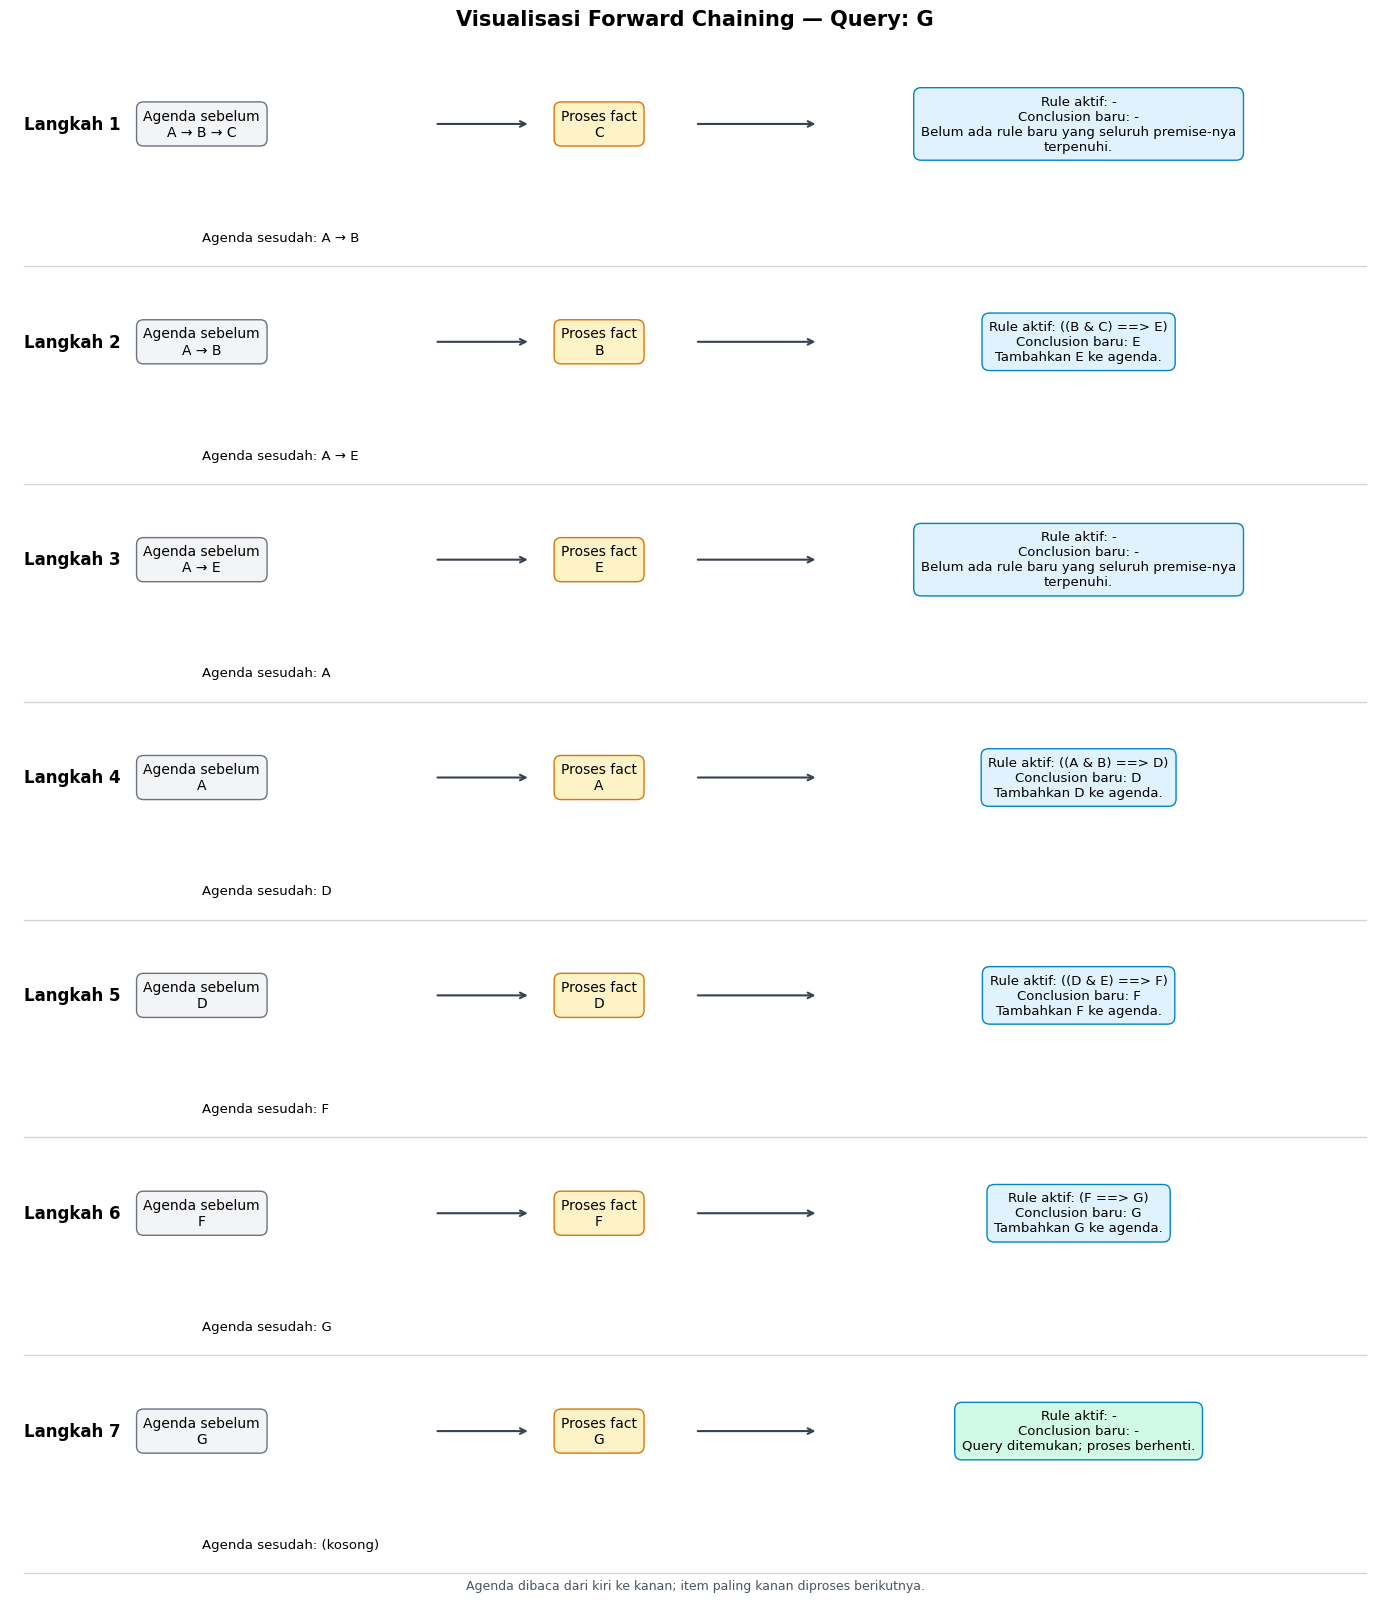

In [62]:
query = "G"
found_fc_exercise, trace_fc_exercise = ask_forward(exercise_kb, query)

print("G berhasil dibuktikan?", found_fc_exercise)
display(trace_fc_exercise)
visualize_forward(trace_fc_exercise)

urutan pemrosesan fakta:

C -> B -> E -> A -> D -> F -> G

rule penurunan fakta:

e diturunkan dari b dan c

d diturunkan dari a dan b

f diturunkan dari d dan e

g diturunkan dari f

alasan urutan fact dan ketergantungan rule:

pemrosesan dimulai dari known facts. saat C dan B dievaluasi, rule B ∧ C -> E dilaksanakan lebih dulu sehingga E masuk agenda sebelum D. setelah A diproses, rule A ∧ B -> D baru aktif. F terbentuk dari gabungan derived facts D dan E, yang akhirnya memicu F -> G

kesimpulan:

found_fc_exercise = True, artinya KB |= G terbukti True. G berhasil diturunkan dengan forward chaining (data-driven) karena semua premis dari tiap rule saling terhubung tanpa ada yang terputus

### Soal 3

Query               : G
Berhasil dibuktikan?: True


,langkah,parent,depth,goal,rule diperiksa,rule berhasil,keputusan,hasil
0,1,-,0,G,(F ==> G),(F ==> G),Semua premise pada rule berhasil dibuktikan.,True
1,2,1,1,F,((D & E) ==> F),((D & E) ==> F),Semua premise pada rule berhasil dibuktikan.,True
2,3,2,2,D,((A & B) ==> D),((A & B) ==> D),Semua premise pada rule berhasil dibuktikan.,True
3,4,3,3,A,-,-,Goal sudah tersedia sebagai fact.,True
4,5,3,3,B,-,-,Goal sudah tersedia sebagai fact.,True
5,6,2,2,E,((B & C) ==> E),((B & C) ==> E),Semua premise pada rule berhasil dibuktikan.,True
6,7,6,3,B,-,-,Goal sudah tersedia sebagai fact.,True
7,8,6,3,C,-,-,Goal sudah tersedia sebagai fact.,True


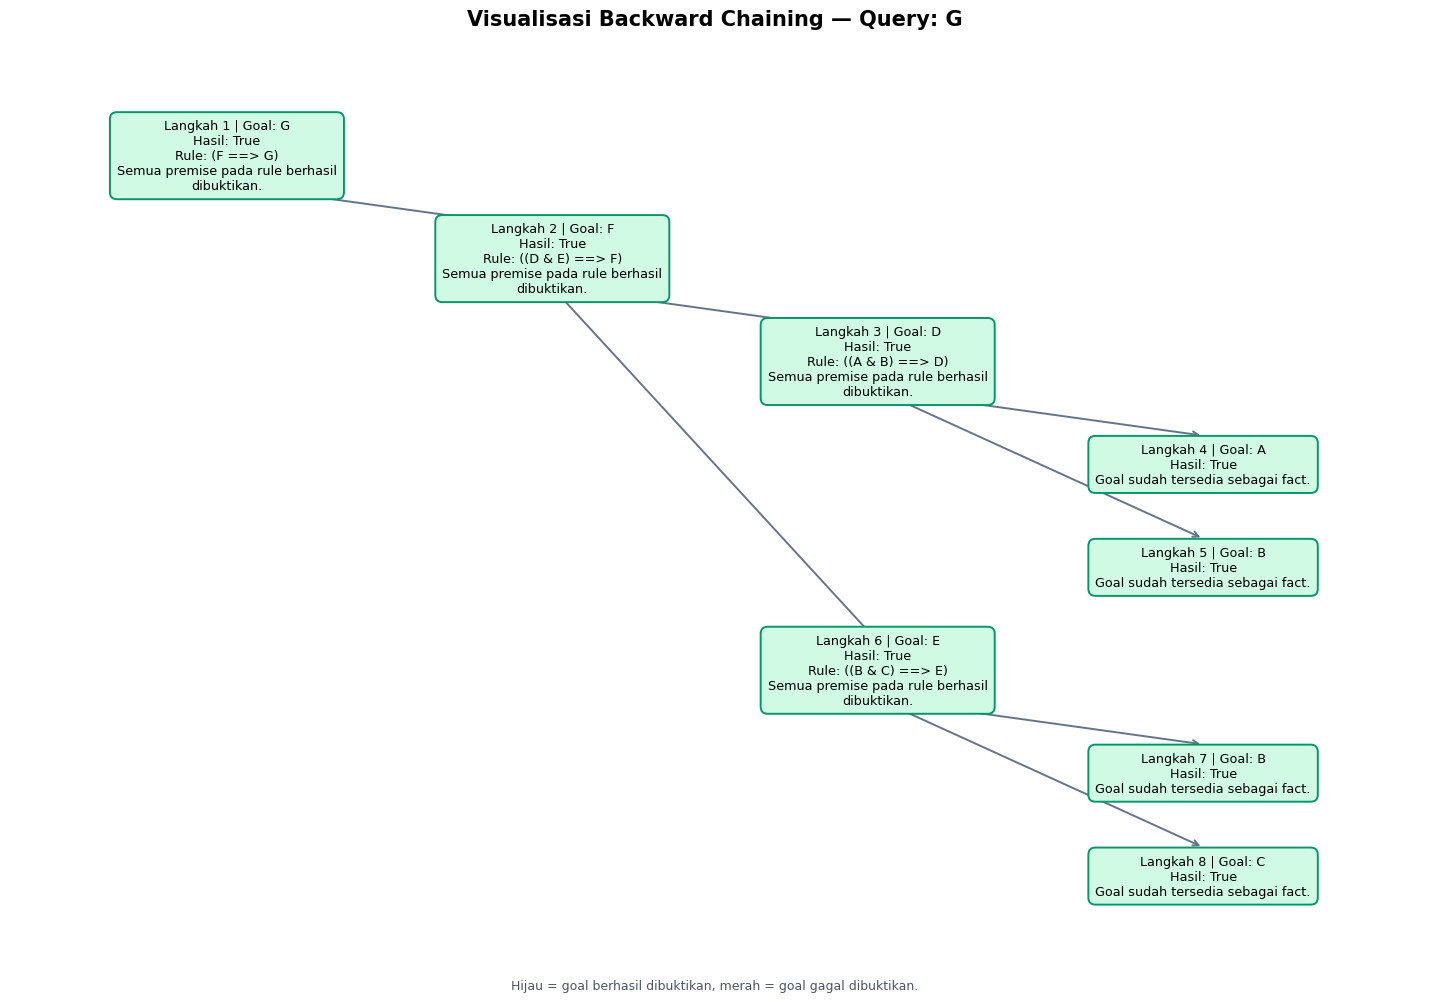

In [63]:
found_bc_exercise, trace_bc_exercise = ask_backward(exercise_kb, query)

print("Query               :", query)
print("Berhasil dibuktikan?:", found_bc_exercise)

display(trace_bc_exercise)
visualize_backward(trace_bc_exercise)

Hasil Pembuktian dan Analisis
komponen tree (root, subgoal, dan leaf fact)
pembagian komponen pada proof tree terdiri dari root yaitu G yang jadi query utama buat dibuktiin, trus ada subgoal yang isinya F, D, dan E sebagai goal perantara yang kudu dicari pembuktiannya satu2, sama terakhir ada leaf fact berupa A, B, dan C yang posisinya sebagai fakta dasar di basis pengetahuan.

alur pembuktian (top down search)
pencarian dimulai secara top down dari query utama G sebagai root, di mana buat membuktikan G sistem perlu menurunkan subgoal F via rule F -> G, lalu buat membuktikan F dibutuhkan dua subgoal yaitu D dan E via rule D & E -> F, lanjut ke subgoal D yang berhasil dibuktiin karena cuma butuh A dan B yang keduanya terdaftar sebagai leaf fact, sedangkan subgoal E juga berhasil dibuktiin gara2 butuh B dan C yang dua2nya juga leaf fact, sehingga karena seluruh leaf node A, B, dan C tervalidasi sebagai fakta awal maka subgoal D dan E bernilai True yang secara otomatis membuktikan F hingga akhirnya G terbukti secara utuuuh.

kesimpulan
found_bc_exercise = True artinya KB |= G terbukti True, di mana query G berhasil dibuktiin lewat pendekatan backward chaining (goal driven) karena seluruh cabang proof tree berujung pada fakta dasar yang valid di KB tanpa ada subgoal yang menggantungg.